In [1]:
from primordialpy.background import Background
from primordialpy.model import PotentialFunction
from primordialpy.perturbations import  Perturbations
from primordialpy.pbhabundance import PBHAbundance
from primordialpy.pbhconstraints import PBHConstraints
from primordialpy.inducedGW import InducedGW


import matplotlib.pyplot as plt

In [2]:
V = 'V0*(tanh(phi/sqrt(6)))**2*(1 + A*(sech((phi - phi0)/sigma))**2)'
parameters = {'V0' : 1.448e-10, 'A' : 2.044880e-3, 'phi0' : 4.850001, 'sigma': 2.524999e-2}
potential = PotentialFunction.from_string(V, param_values=parameters) 

#Creando instancia de la clase Background. 
background = Background(potential, phi0 = 6.3) 
background.solver()

In [3]:
#Extrayendo datos de la clase background

vars = ['N', 'phi', 'dphidN', 'H', 'a', 'aH', 'eps_H', 'eta_H']
N, phi, dphidN, H, a, aH, eps_H, eta_H = (background.data(save=True)[i] for i in vars)

In [4]:
pert = Perturbations(potential, background, scale= 'PBH', N_CMB = 60)
P_s = pert.Power_spectrum(save=True)

Computing P(k): 100%|██████████| 1000/1000 [00:38<00:00, 26.29it/s]


k_peak = 4.80\times 10^{+12} Mpc^-1
N_peak = 46.06436516506511
P_s(k_peak) = 0.030778381489592718
Figure saved as: Figures/spectrum_scalar.pdf


<Figure size 2400x1500 with 0 Axes>

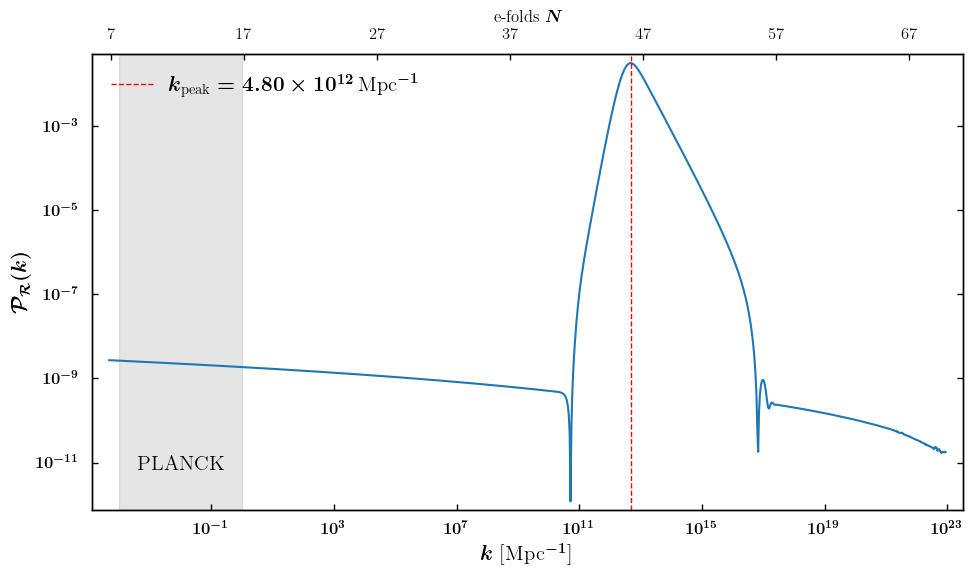

In [5]:
pert.Plot_spectrum(spectrum= 'scalar', dpi= 300, save=True)

In [6]:
pert.Spectral_tilts

{'n_s': 0.9608726512208808, 'n_t': -0.0005864031944023213}

In [7]:
pert.Power_spectra_pivot()

Curvature power spectrum at pivot scale is 2.1041147889913456e-09
Tensor to scalar ratio at pivot scale is 0.004512400400109408


(2.1041147889913456e-09, 9.49460841572067e-12, 0.004512400400109408)

## PBH Abundance after re-entry horizon in RD era

In [8]:
pbh = PBHAbundance(pert, delta_c=0.4, gamma=0.2, gstar=107.5)
mPBH, fPBH = pbh.fPBH(save=True)

fPBH_peak = 0.8940512908723645
MPBH_peak = 1.5888386777058603e-13 M⊙


  [OK] Loaded data: Evap
  [OK] Loaded data: HSC
  [ERROR] Failure to read CMB.txt: the number of columns changed from 2 to 1 at row 9; use `usecols` to select a subset and avoid this error
  [OK] Loaded data: LIGO
  [OK] Loaded data: Accretion
  [OK] Loaded data: Dynamical
  [OK] Loaded data: EROS
  [OK] Loaded data: Kepler
  [OK] Loaded data: Microlensing
fPBH_peak = 0.8940512908723645
MPBH_peak = 1.5888386777058603e-13 M⊙
fPBH_peak = 0.8940512908723645
MPBH_peak = 1.5888386777058603e-13 M⊙
Figure saved to: Figures/Paper_Figure_Final.pdf


<Figure size 2400x1500 with 0 Axes>

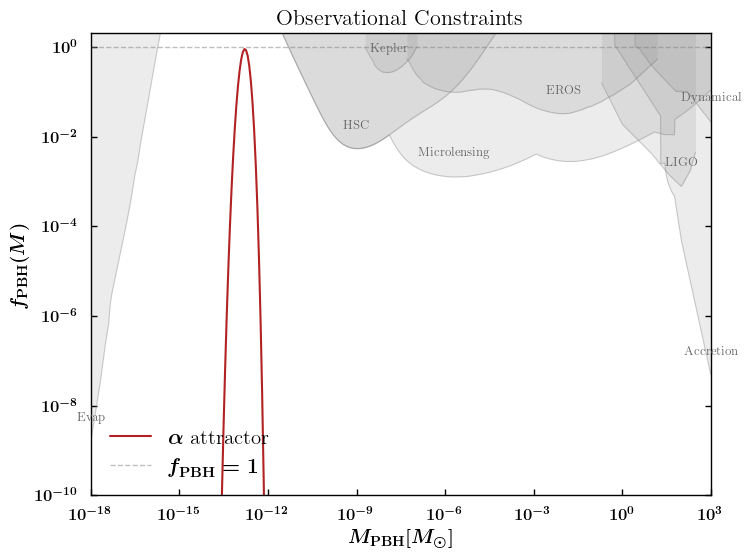

In [9]:
constraints = PBHConstraints()
constraints.add_bound('Evap', 'Evaporation.txt')
constraints.add_bound('HSC',  'HSC.txt')
constraints.add_bound('CMB', 'CMB.txt')
constraints.add_bound('LIGO', 'LIGO.txt')
constraints.add_bound('Accretion', 'Accretion.txt')
constraints.add_bound('Dynamical', 'Dynamical.txt')
constraints.add_bound('EROS', 'EROS.txt')
constraints.add_bound('Kepler', 'Kepler.txt')
constraints.add_bound('Microlensing', 'Microlensing.txt')


constraints.plot_constraints(pbh, label= r"$\alpha$ attractor", filename='Paper_Figure_Final.pdf')

Computing SIGW for 1000 modes...
Omega_GW_peak = 8.368403965818259e-09
f_peak = 0.00841139352669591 Hz


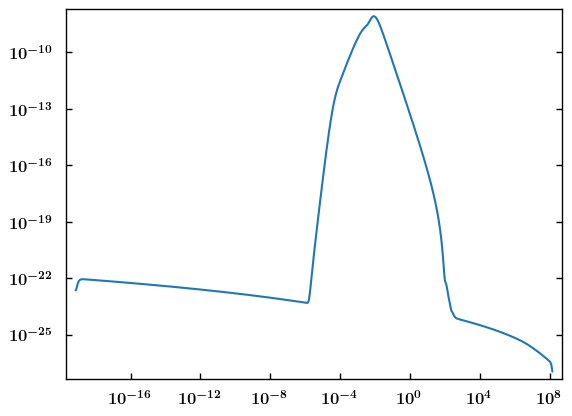

In [10]:
gw = InducedGW(perturbations=pert)
f, omega = gw.compute(n_int= 500, save=True)
plt.loglog(f, omega)